# Task 3 — GNN Improvement, Ablation & Explainability

**Group 11 · CSE475 Machine Learning · Summer 2026**

This notebook implements the full Task 3 pipeline:
1. Ablation study (layers, hidden size, dropout, batch norm, LR schedule, optimizer, graph construction, edge weights, GNN variant, imbalance handling, early stopping)
2. Final improved GNN vs baselines
3. 5-fold subject cross-validation + significance test
4. SHAP + LIME explainability

**Baseline to beat:** MLP at 55.02% (Task 2)

---
**Prerequisites:** Run Task 2 baseline notebook first so that preprocessed data is available,
OR set `DATA_DIR` below and this notebook will reload from scratch.

## Setup & Shared Utilities

In [1]:
# ── Installs (run once) ──
!pip install torch-geometric shap lime scipy scikit-learn -q

In [2]:
import os, re, warnings, itertools
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from collections import defaultdict
from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import wilcoxon
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Path ──
DATA_DIR = r"C:\Users\User\Downloads\FORS-EMG Dataset\FORS-EMG Dataset\FORS-EMG"

# ── Constants ──
FS          = 985
WINDOW_SIZE = 492
STRIDE      = 246
N_CH        = 8
N_CLASSES   = 12
PAIRS       = list(combinations(range(N_CH), 2))  # 28 pairs

TRAIN_SUBJECTS = [f'Subject{i}' for i in range(1, 16)]
VAL_SUBJECTS   = ['Subject16', 'Subject17']
TEST_SUBJECTS  = ['Subject18', 'Subject19']
ALL_SUBJECTS   = TRAIN_SUBJECTS + VAL_SUBJECTS + TEST_SUBJECTS  # for 5-fold CV

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch:', torch.__version__)

Device: cuda
PyTorch: 2.10.0


In [3]:
# ── Signal preprocessing ──
def make_bandpass(lo=20, hi=450, fs=FS, order=4):
    nyq = fs / 2
    b, a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return b, a

def make_notch(freq=50, q=30, fs=FS):
    b, a = iirnotch(freq / (fs/2), q)
    return b, a

BP_B, BP_A = make_bandpass()
NT_B, NT_A = make_notch()

def preprocess(signal):
    """Bandpass 20-450Hz + Notch 50Hz. signal: (8, 8000)"""
    out = np.zeros_like(signal, dtype=np.float64)
    for ch in range(signal.shape[0]):
        x = filtfilt(BP_B, BP_A, signal[ch].astype(np.float64))
        out[ch] = filtfilt(NT_B, NT_A, x)
    return out

# ── Windowing ──
def make_windows(signal):
    """Returns (n_windows, 8, 492)"""
    starts = range(0, signal.shape[1] - WINDOW_SIZE + 1, STRIDE)
    return np.stack([signal[:, s:s+WINDOW_SIZE] for s in starts])

# ── TSD features (7 per channel) ──
def _tsd_single(x):
    eps = 1e-10
    dx  = np.diff(x, prepend=x[0])
    d2x = np.diff(x, n=2, prepend=[x[0], x[0]])
    m0  = np.sqrt(np.mean(x**2))
    m2  = np.sqrt(np.mean(dx**2))
    m4  = np.sqrt(np.mean(d2x**2))
    spar = np.log(np.abs((np.sqrt(m0)/(m0-m2+eps))*(np.sqrt(m0)-m4+eps)) + eps)
    irf  = np.log(m2/(np.sqrt(m0*m4)+eps) + eps)
    cov  = np.log(np.std(x)/(np.abs(np.mean(x))+eps) + eps)
    tkeo = np.log(np.sum(np.abs(x[1:-1]**2 - x[:-2]*x[2:])) + eps)
    return np.array([m0, m2, m4, spar, irf, cov, tkeo], dtype=np.float32)

def extract_node_features(window):
    """window: (8, 492) → X: (8, 7)"""
    return np.stack([_tsd_single(window[ch]) for ch in range(N_CH)])

print('Preprocessing and feature functions ready.')

Preprocessing and feature functions ready.


In [4]:
# ── Adjacency matrix construction (graph construction) ──

# Spatial adjacency (fixed — anatomical connections)
# Elbow group: CH0-CH3 fully connected
# Mid-forearm: CH4-CH7 fully connected
# Cross-location aligned pairs: 0↔4, 1↔5, 2↔6, 3↔7
def make_spatial_adj():
    A = np.zeros((N_CH, N_CH), dtype=np.float32)
    # Elbow group
    for i, j in combinations(range(4), 2):
        A[i, j] = A[j, i] = 1.0
    # Mid-forearm group
    for i, j in combinations(range(4, 8), 2):
        A[i, j] = A[j, i] = 1.0
    # Aligned cross-location pairs
    for k in range(4):
        A[k, k+4] = A[k+4, k] = 1.0
    return A

SPATIAL_ADJ = make_spatial_adj()

def make_correlation_adj(window, threshold=0.3):
    """Pearson correlation adjacency matrix for one window."""
    C = np.corrcoef(window)          # (8, 8)
    A = np.abs(C).astype(np.float32)
    np.fill_diagonal(A, 0)
    A[A < threshold] = 0
    return A

def make_combined_adj(window, threshold=0.3):
    """Spatial + correlation (union, weights from correlation)."""
    A_corr = make_correlation_adj(window, threshold)
    # Ensure spatial edges are always present with at least weight 0.5
    A = A_corr.copy()
    A = np.maximum(A, SPATIAL_ADJ * 0.5)
    return A

def normalize_adj(A):
    """Symmetric normalisation: D^(-1/2) (A+I) D^(-1/2)"""
    A = A + np.eye(N_CH, dtype=np.float32)  # self-loops
    D = np.diag(A.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D) + 1e-10))
    return D_inv_sqrt @ A @ D_inv_sqrt

print('Graph construction functions ready.')
print('Spatial adjacency matrix (8×8):')
print(SPATIAL_ADJ.astype(int))

Graph construction functions ready.
Spatial adjacency matrix (8×8):
[[0 1 1 1 1 0 0 0]
 [1 0 1 1 0 1 0 0]
 [1 1 0 1 0 0 1 0]
 [1 1 1 0 0 0 0 1]
 [1 0 0 0 0 1 1 1]
 [0 1 0 0 1 0 1 1]
 [0 0 1 0 1 1 0 1]
 [0 0 0 1 1 1 1 0]]


In [10]:
# ── Data loading for GNN ──
# ============================================================
# GNN DATA LOADING PIPELINE
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import scipy.io as sio

from pathlib import Path
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder

import torch
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. DATASET PATH
# ============================================================

DATA_DIR = r"C:\Users\Asus\Documents\Group11_Fors_EMG_Project\Fors_EMG_Dataset"

print("Dataset path:")
print(DATA_DIR)

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f"\nDataset folder not found!\n"
        f"Check DATA_DIR:\n{DATA_DIR}"
    )

print("Dataset path exists: YES")


# ============================================================
# 2. LOAD METADATA
# ============================================================

def load_metadata(data_dir):

    records = []

    for root, _, files in os.walk(data_dir):

        for f in files:

            # Only process .mat files
            if not f.lower().endswith(".mat"):
                continue

            fpath = os.path.join(root, f)

            # ------------------------------------------------
            # Get folder information
            # ------------------------------------------------
            parts = Path(fpath).parts

            # Expected structure:
            #
            # Fors_EMG_Dataset/
            #     Subject1/
            #         pronation/
            #             file.mat
            #
            # Therefore:
            # parts[-3] = Subject
            # parts[-2] = Orientation
            # ------------------------------------------------

            if len(parts) < 3:
                print("Skipping unexpected path:")
                print(fpath)
                continue

            subject = parts[-3]
            orientation = parts[-2]

            # ------------------------------------------------
            # Extract gesture and trial from filename
            # Example:
            # Hand_Close-1.mat
            #
            # Gesture = Hand_Close
            # Trial   = 1
            # ------------------------------------------------

            name = Path(f).stem

            m = re.match(r"(.+)-(\d+)$", name)

            if m:

                gesture = m.group(1)
                trial = int(m.group(2))

            else:

                gesture = name
                trial = 0

            records.append({
                "File": fpath,
                "Subject": subject,
                "Orientation": orientation,
                "Gesture": gesture,
                "Trial": trial
            })

    # --------------------------------------------------------
    # Explicit columns
    # This prevents an empty DataFrame from having no columns.
    # --------------------------------------------------------

    columns = [
        "File",
        "Subject",
        "Orientation",
        "Gesture",
        "Trial"
    ]

    metadata = pd.DataFrame(records, columns=columns)

    return metadata


# Load metadata
metadata = load_metadata(DATA_DIR)


# ============================================================
# 3. CHECK METADATA
# ============================================================

print("\n" + "=" * 60)
print("METADATA INFORMATION")
print("=" * 60)

print("Total MAT files :", len(metadata))
print("Columns         :", metadata.columns.tolist())


# Check if dataset is empty
if metadata.empty:
    raise ValueError(
        "\nNo .mat files were found!\n"
        "Please check your DATA_DIR and dataset folder structure."
    )


print("Subjects        :", metadata["Subject"].nunique())
print("Orientations    :", metadata["Orientation"].nunique())
print("Gestures        :", metadata["Gesture"].nunique())


# ============================================================
# 4. DISPLAY GESTURES
# ============================================================

print("\nGesture classes:")

gesture_names = sorted(metadata["Gesture"].unique())

for i, gesture in enumerate(gesture_names):
    print(f"{i}: {gesture}")


# ============================================================
# 5. LABEL ENCODING
# ============================================================

le = LabelEncoder()

le.fit(gesture_names)

print("\nLabelEncoder classes:")
print(list(le.classes_))

print("Number of classes:", len(le.classes_))


# ============================================================
# 6. GNN DATA PROCESSING
# ============================================================

def process_split_gnn(df, adj_fn, desc="GNN data"):
    """
    Load signals → preprocess → window →
    extract node features and adjacency matrices.

    Returns
    -------
    X : numpy array
        Shape: (number_of_windows, 8, 7)

    A : numpy array
        Shape: (number_of_windows, 8, 8)

    y : numpy array
        Shape: (number_of_windows,)
    """

    X_list = []
    A_list = []
    y_list = []

    # --------------------------------------------------------
    # Process each MAT file
    # --------------------------------------------------------

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc=desc
    ):

        # ----------------------------------------------------
        # Load MAT file
        # ----------------------------------------------------

        mat_data = sio.loadmat(row["File"])

        if "value" not in mat_data:
            raise KeyError(
                f"\n'value' variable not found in:\n{row['File']}\n"
                f"Available variables: {list(mat_data.keys())}"
            )

        raw = mat_data["value"]

        # Expected:
        # raw.shape = (8, 8000)

        # ----------------------------------------------------
        # Preprocessing
        # ----------------------------------------------------

        proc = preprocess(raw)

        # ----------------------------------------------------
        # Windowing
        # ----------------------------------------------------

        wins = make_windows(proc)

        # ----------------------------------------------------
        # Process each window
        # ----------------------------------------------------

        for w in wins:

            # Node features
            # Expected shape: (8, 7)
            node_features = extract_node_features(w)

            # Adjacency matrix
            # Expected shape: (8, 8)
            adjacency = normalize_adj(adj_fn(w))

            # Label
            label = le.transform(
                [row["Gesture"]]
            )[0]

            X_list.append(node_features)
            A_list.append(adjacency)
            y_list.append(label)

    # --------------------------------------------------------
    # Convert lists to NumPy arrays
    # --------------------------------------------------------

    X = np.array(
        X_list,
        dtype=np.float32
    )

    A = np.array(
        A_list,
        dtype=np.float32
    )

    y = np.array(
        y_list,
        dtype=np.int64
    )

    return X, A, y


# ============================================================
# 7. CREATE PYTORCH GNN DATALOADER
# ============================================================

def make_gnn_loader(
    X,
    A,
    y,
    batch_size=256,
    shuffle=True
):
    """
    Convert NumPy arrays into a PyTorch DataLoader.
    """

    # Convert NumPy → PyTorch tensors

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    )

    A_tensor = torch.tensor(
        A,
        dtype=torch.float32
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.long
    )

    # Create TensorDataset

    ds = TensorDataset(
        X_tensor,
        A_tensor,
        y_tensor
    )

    # Create DataLoader

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0
    )

    return loader


# ============================================================
# 8. FINAL CHECK
# ============================================================

print("\n" + "=" * 60)
print("GNN DATA LOADING FUNCTIONS READY")
print("=" * 60)

print("load_metadata()       : READY")
print("process_split_gnn()   : READY")
print("make_gnn_loader()     : READY")
print("LabelEncoder          : READY")

print("\nEverything is ready for GNN processing.")

Dataset path:
C:\Users\Asus\Documents\Group11_Fors_EMG_Project\Fors_EMG_Dataset
Dataset path exists: YES

METADATA INFORMATION
Total MAT files : 3420
Columns         : ['File', 'Subject', 'Orientation', 'Gesture', 'Trial']
Subjects        : 19
Orientations    : 6
Gestures        : 12

Gesture classes:
0: Hand_Close
1: Hand_Open
2: Index
3: Index_Little
4: Peace
5: Radial_Deviation
6: Right_Angle
7: Thumb_Little
8: Thumb_UP
9: Ulner_Deviation
10: Wrist_Extension
11: Wrist_Flexion

LabelEncoder classes:
[np.str_('Hand_Close'), np.str_('Hand_Open'), np.str_('Index'), np.str_('Index_Little'), np.str_('Peace'), np.str_('Radial_Deviation'), np.str_('Right_Angle'), np.str_('Thumb_Little'), np.str_('Thumb_UP'), np.str_('Ulner_Deviation'), np.str_('Wrist_Extension'), np.str_('Wrist_Flexion')]
Number of classes: 12

GNN DATA LOADING FUNCTIONS READY
load_metadata()       : READY
process_split_gnn()   : READY
make_gnn_loader()     : READY
LabelEncoder          : READY

Everything is ready for GNN 

In [11]:
# ── Load data with combined adjacency (default) ──
train_meta = metadata[metadata.Subject.isin(TRAIN_SUBJECTS)].reset_index(drop=True)
val_meta   = metadata[metadata.Subject.isin(VAL_SUBJECTS)].reset_index(drop=True)
test_meta  = metadata[metadata.Subject.isin(TEST_SUBJECTS)].reset_index(drop=True)

print('Loading train...')
X_tr, A_tr, y_tr = process_split_gnn(train_meta, make_combined_adj, 'Train')
print('Loading val...')
X_v,  A_v,  y_v  = process_split_gnn(val_meta,   make_combined_adj, 'Val  ')
print('Loading test...')
X_te, A_te, y_te = process_split_gnn(test_meta,  make_combined_adj, 'Test ')

# Channel-wise normalisation (fit on train)
feat_mean = X_tr.mean(axis=(0,2), keepdims=True)  # (1,8,1)
feat_std  = X_tr.std(axis=(0,2),  keepdims=True)
feat_std[feat_std == 0] = 1.0

X_tr = np.clip(np.nan_to_num((X_tr - feat_mean) / feat_std), -1e6, 1e6)
X_v  = np.clip(np.nan_to_num((X_v  - feat_mean) / feat_std), -1e6, 1e6)
X_te = np.clip(np.nan_to_num((X_te - feat_mean) / feat_std), -1e6, 1e6)

print(f'X_train: {X_tr.shape} | A_train: {A_tr.shape} | y_train: {y_tr.shape}')
print(f'X_val  : {X_v.shape}  | X_test : {X_te.shape}')

Loading train...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

Loading val...


Val  :   0%|          | 0/360 [00:00<?, ?it/s]

Loading test...


Test :   0%|          | 0/360 [00:00<?, ?it/s]

X_train: (83700, 8, 7) | A_train: (83700, 8, 8) | y_train: (83700,)
X_val  : (11160, 8, 7)  | X_test : (11160, 8, 7)


## GNN Model Definitions

In [12]:
class GNNLayer(nn.Module):
    """Standard graph message passing: H' = σ(A_norm H W)"""
    def __init__(self, in_dim, out_dim, use_bn=True, dropout=0.3, activation=True):
        super().__init__()
        self.linear   = nn.Linear(in_dim, out_dim, bias=False)
        self.bn       = nn.BatchNorm1d(out_dim) if use_bn else nn.Identity()
        self.dropout  = nn.Dropout(dropout)
        self.activation = activation

    def forward(self, H, A_norm):
        # H: (B, N, d_in) | A_norm: (B, N, N)
        H = torch.bmm(A_norm, H)      # aggregate neighbours
        H = self.linear(H)             # linear transform
        B, N, D = H.shape
        H = self.bn(H.reshape(B*N, D)).reshape(B, N, D)
        if self.activation:
            H = F.relu(H)
        H = self.dropout(H)
        return H


class GATLayer(nn.Module):
    """Graph Attention layer (single head, simplified)."""
    def __init__(self, in_dim, out_dim, use_bn=True, dropout=0.3, activation=True):
        super().__init__()
        self.W  = nn.Linear(in_dim, out_dim, bias=False)
        self.a  = nn.Linear(2 * out_dim, 1, bias=False)
        self.bn = nn.BatchNorm1d(out_dim) if use_bn else nn.Identity()
        self.dropout  = nn.Dropout(dropout)
        self.activation = activation

    def forward(self, H, A_norm):
        # H: (B, N, d_in)
        Wh = self.W(H)                 # (B, N, d_out)
        B, N, D = Wh.shape
        # Attention: e_ij = LeakyReLU([Wh_i || Wh_j] a)
        Wh_i = Wh.unsqueeze(2).expand(B, N, N, D)
        Wh_j = Wh.unsqueeze(1).expand(B, N, N, D)
        e = F.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)).squeeze(-1), 0.2)
        # Mask non-edges
        mask = (A_norm == 0)
        e = e.masked_fill(mask, float('-inf'))
        alpha = F.softmax(e, dim=-1)   # (B, N, N)
        H_new = torch.bmm(alpha, Wh)   # (B, N, D)
        H_new = self.bn(H_new.reshape(B*N, D)).reshape(B, N, D)
        if self.activation:
            H_new = F.elu(H_new)
        return self.dropout(H_new)


class GNNClassifier(nn.Module):
    """
    Configurable GNN for ablation study.
    variant: 'gnn' or 'gat'
    """
    def __init__(self,
                 in_dim    = 7,
                 hidden    = [64, 128],
                 out_dim   = 64,
                 n_classes = N_CLASSES,
                 dropout   = 0.3,
                 use_bn    = True,
                 variant   = 'gnn'):
        super().__init__()
        Layer = GATLayer if variant == 'gat' else GNNLayer
        dims  = [in_dim] + hidden + [out_dim]
        self.layers = nn.ModuleList([
            Layer(dims[i], dims[i+1], use_bn=use_bn,
                  dropout=dropout, activation=(i < len(dims)-2))
            for i in range(len(dims)-1)
        ])
        readout_dim = out_dim * 2   # mean + max pool
        self.head = nn.Sequential(
            nn.Linear(readout_dim, readout_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(readout_dim // 2, n_classes)
        )

    def forward(self, X, A):
        H = X
        for layer in self.layers:
            H = layer(H, A)
        # Readout: mean + max pool over nodes
        h_mean = H.mean(dim=1)
        h_max  = H.max(dim=1).values
        g = torch.cat([h_mean, h_max], dim=-1)
        return self.head(g)


# Quick test
m = GNNClassifier().to(device)
xb = torch.randn(4, 8, 7).to(device)
ab = torch.randn(4, 8, 8).to(device)
print('GNN output shape:', m(xb, ab).shape)
print('Parameters:', sum(p.numel() for p in m.parameters() if p.requires_grad))

GNN output shape: torch.Size([4, 12])
Parameters: 26380


In [13]:
# ── Training loop ──
def train_gnn(config, X_tr, A_tr, y_tr, X_v, A_v, y_v, verbose=True):
    """
    config keys:
      hidden, out_dim, dropout, use_bn, variant, optimizer,
      lr, epochs, batch_size, use_scheduler, use_early_stop,
      patience, class_weights
    """
    model = GNNClassifier(
        hidden  = config.get('hidden', [64, 128]),
        out_dim = config.get('out_dim', 64),
        dropout = config.get('dropout', 0.3),
        use_bn  = config.get('use_bn', True),
        variant = config.get('variant', 'gnn')
    ).to(device)

    # Optimiser
    opt_name = config.get('optimizer', 'adam')
    lr = config.get('lr', 1e-3)
    if opt_name == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    elif opt_name == 'adamw':
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    elif opt_name == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

    # Scheduler
    epochs = config.get('epochs', 50)
    sched = None
    sched_name = config.get('use_scheduler', 'cosine')
    if sched_name == 'cosine':
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    elif sched_name == 'step':
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=20, gamma=0.5)
    elif sched_name == 'none':
        sched = None

    # Loss — imbalance handling
    cw = config.get('class_weights', None)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device) if cw else None
    )

    bs = config.get('batch_size', 256)
    train_loader = make_gnn_loader(X_tr, A_tr, y_tr, bs, shuffle=True)
    val_loader   = make_gnn_loader(X_v,  A_v,  y_v,  bs, shuffle=False)

    patience   = config.get('patience', 10)
    early_stop = config.get('use_early_stop', True)
    best_acc, no_improve = 0.0, 0
    best_wts = None
    history   = defaultdict(list)

    for epoch in range(1, epochs+1):
        # Train
        model.train()
        tr_loss = tr_correct = tr_total = 0
        for Xb, Ab, yb in train_loader:
            Xb, Ab, yb = Xb.to(device), Ab.to(device), yb.to(device)
            opt.zero_grad()
            out  = model(Xb, Ab)
            loss = criterion(out, yb)
            loss.backward()
            opt.step()
            tr_loss    += loss.item() * len(yb)
            tr_correct += (out.argmax(1) == yb).sum().item()
            tr_total   += len(yb)
        if sched: sched.step()

        # Validate
        model.eval()
        v_correct = v_total = 0
        with torch.no_grad():
            for Xb, Ab, yb in val_loader:
                Xb, Ab = Xb.to(device), Ab.to(device)
                out = model(Xb, Ab)
                v_correct += (out.argmax(1) == yb.to(device)).sum().item()
                v_total   += len(yb)

        v_acc = v_correct / v_total
        history['val_acc'].append(v_acc)
        history['train_acc'].append(tr_correct / tr_total)

        if v_acc > best_acc:
            best_acc = v_acc
            best_wts = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch:02d}/{epochs}  train_acc={tr_correct/tr_total:.4f}  val_acc={v_acc:.4f}')

        if early_stop and no_improve >= patience:
            if verbose: print(f'  Early stop at epoch {epoch}')
            break

    model.load_state_dict(best_wts)
    return model, best_acc, history


def eval_model(model, X, A, y, batch_size=256):
    loader = make_gnn_loader(X, A, y, batch_size, shuffle=False)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, Ab, yb in loader:
            out = model(Xb.to(device), Ab.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    preds, trues = np.array(preds), np.array(trues)
    return {
        'accuracy': accuracy_score(trues, preds),
        'macro_f1': f1_score(trues, preds, average='macro'),
        'preds': preds, 'trues': trues
    }

print('Training utilities ready.')

Training utilities ready.


## Ablation Study

One variable changes at a time. All other settings stay at the **default config** below.

In [14]:
# ── Default (base) configuration ──
DEFAULT = dict(
    hidden         = [64, 128],
    out_dim        = 64,
    dropout        = 0.3,
    use_bn         = True,
    variant        = 'gnn',
    optimizer      = 'adam',
    lr             = 1e-3,
    epochs         = 50,
    batch_size     = 256,
    use_scheduler  = 'cosine',
    use_early_stop = True,
    patience       = 10,
    class_weights  = None,
)

ablation_results = {}  # store all experiment results

def run_ablation(name, overrides, adj_fn=None):
    """Run one ablation experiment."""
    cfg = {**DEFAULT, **overrides}
    _adj = adj_fn if adj_fn else make_combined_adj
    # Use pre-loaded data or reload if adj_fn differs
    if adj_fn is None:
        _X_tr, _A_tr, _y_tr = X_tr, A_tr, y_tr
        _X_v,  _A_v,  _y_v  = X_v,  A_v,  y_v
    else:
        print(f'  Reloading data with custom adjacency...')
        _X_tr, _A_tr, _y_tr = process_split_gnn(train_meta, _adj, 'Train')
        _X_v,  _A_v,  _y_v  = process_split_gnn(val_meta,   _adj, 'Val  ')
        _X_tr = np.clip(np.nan_to_num((_X_tr - feat_mean) / feat_std), -1e6, 1e6)
        _X_v  = np.clip(np.nan_to_num((_X_v  - feat_mean) / feat_std), -1e6, 1e6)

    print(f'\n[{name}]')
    model, best_acc, history = train_gnn(cfg, _X_tr, _A_tr, _y_tr, _X_v, _A_v, _y_v, verbose=True)
    metrics = eval_model(model, _X_v, _A_v, _y_v)
    ablation_results[name] = metrics
    print(f'  → val acc: {metrics["accuracy"]:.4f}  macro F1: {metrics["macro_f1"]:.4f}')
    return model, metrics, history

print('Ablation framework ready. Starting experiments...')

Ablation framework ready. Starting experiments...


In [15]:
# ── A. Default (baseline GNN) ──
m_default, r_default, h_default = run_ablation('A. Default GNN', {})


[A. Default GNN]
  Epoch 10/50  train_acc=0.4373  val_acc=0.2716
  Early stop at epoch 16
  → val acc: 0.2855  macro F1: 0.2725


In [16]:
# ── B. Vary number of GNN layers ──
run_ablation('B1. 2 layers',  {'hidden': [64]})
run_ablation('B2. 3 layers',  {'hidden': [64, 128]})          # same as default
run_ablation('B3. 4 layers',  {'hidden': [64, 128, 128]})


[B1. 2 layers]
  Epoch 10/50  train_acc=0.4218  val_acc=0.2537
  Epoch 20/50  train_acc=0.4514  val_acc=0.2751
  Epoch 30/50  train_acc=0.4661  val_acc=0.2646
  Early stop at epoch 36
  → val acc: 0.2822  macro F1: 0.2470

[B2. 3 layers]
  Epoch 10/50  train_acc=0.4381  val_acc=0.2583
  Early stop at epoch 16
  → val acc: 0.2999  macro F1: 0.2756

[B3. 4 layers]
  Epoch 10/50  train_acc=0.4451  val_acc=0.2618
  Epoch 20/50  train_acc=0.4976  val_acc=0.2779
  Early stop at epoch 27
  → val acc: 0.2919  macro F1: 0.2662


(GNNClassifier(
   (layers): ModuleList(
     (0): GNNLayer(
       (linear): Linear(in_features=7, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GNNLayer(
       (linear): Linear(in_features=64, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GNNLayer(
       (linear): Linear(in_features=128, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (3): GNNLayer(
       (linear): Linear(in_features=128, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
 

In [17]:
# ── C. Vary hidden size ──
run_ablation('C1. hidden [32, 64]',   {'hidden': [32, 64],   'out_dim': 32})
run_ablation('C2. hidden [64, 128]',  {'hidden': [64, 128],  'out_dim': 64})   # default
run_ablation('C3. hidden [128, 256]', {'hidden': [128, 256], 'out_dim': 128})


[C1. hidden [32, 64]]
  Epoch 10/50  train_acc=0.3578  val_acc=0.2720
  Early stop at epoch 17
  → val acc: 0.2834  macro F1: 0.2532

[C2. hidden [64, 128]]
  Epoch 10/50  train_acc=0.4359  val_acc=0.2691
  Early stop at epoch 18
  → val acc: 0.2815  macro F1: 0.2536

[C3. hidden [128, 256]]
  Epoch 10/50  train_acc=0.5087  val_acc=0.2832
  Epoch 20/50  train_acc=0.5702  val_acc=0.2643
  Early stop at epoch 20
  → val acc: 0.2832  macro F1: 0.2481


(GNNClassifier(
   (layers): ModuleList(
     (0): GNNLayer(
       (linear): Linear(in_features=7, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GNNLayer(
       (linear): Linear(in_features=128, out_features=256, bias=False)
       (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GNNLayer(
       (linear): Linear(in_features=256, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
   (head): Sequential(
     (0): Linear(in_features=256, out_features=128, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=128, out_features=12, bias=True)
   )
 ),
 {'accuracy': 0.283243

In [18]:
# ── D. Vary dropout ──
for dr in [0.1, 0.2, 0.3, 0.4, 0.5]:
    run_ablation(f'D. dropout={dr}', {'dropout': dr})


[D. dropout=0.1]
  Epoch 10/50  train_acc=0.5136  val_acc=0.2757
  Epoch 20/50  train_acc=0.5779  val_acc=0.2667
  Early stop at epoch 23
  → val acc: 0.3092  macro F1: 0.2920

[D. dropout=0.2]
  Epoch 10/50  train_acc=0.4700  val_acc=0.2764
  Epoch 20/50  train_acc=0.5204  val_acc=0.2960
  Early stop at epoch 29
  → val acc: 0.3181  macro F1: 0.3066

[D. dropout=0.3]
  Epoch 10/50  train_acc=0.4306  val_acc=0.2659
  Epoch 20/50  train_acc=0.4809  val_acc=0.2857
  Epoch 30/50  train_acc=0.5045  val_acc=0.2840
  Early stop at epoch 30
  → val acc: 0.2857  macro F1: 0.2666

[D. dropout=0.4]
  Epoch 10/50  train_acc=0.3949  val_acc=0.2528
  Epoch 20/50  train_acc=0.4362  val_acc=0.2937
  Epoch 30/50  train_acc=0.4536  val_acc=0.2788
  Early stop at epoch 30
  → val acc: 0.2937  macro F1: 0.2608

[D. dropout=0.5]
  Epoch 10/50  train_acc=0.3561  val_acc=0.2565
  Early stop at epoch 19
  → val acc: 0.2970  macro F1: 0.2693


In [19]:
# ── E. Batch normalisation on/off ──
run_ablation('E1. BatchNorm ON',  {'use_bn': True})   # default
run_ablation('E2. BatchNorm OFF', {'use_bn': False})


[E1. BatchNorm ON]
  Epoch 10/50  train_acc=0.4334  val_acc=0.2613
  Epoch 20/50  train_acc=0.4775  val_acc=0.2701
  Early stop at epoch 29
  → val acc: 0.2884  macro F1: 0.2687

[E2. BatchNorm OFF]
  Epoch 10/50  train_acc=0.2496  val_acc=0.1175
  Epoch 20/50  train_acc=0.2842  val_acc=0.1512
  Epoch 30/50  train_acc=0.3080  val_acc=0.1857
  Epoch 40/50  train_acc=0.3173  val_acc=0.1808
  Early stop at epoch 42
  → val acc: 0.1953  macro F1: 0.1431


(GNNClassifier(
   (layers): ModuleList(
     (0): GNNLayer(
       (linear): Linear(in_features=7, out_features=64, bias=False)
       (bn): Identity()
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GNNLayer(
       (linear): Linear(in_features=64, out_features=128, bias=False)
       (bn): Identity()
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GNNLayer(
       (linear): Linear(in_features=128, out_features=64, bias=False)
       (bn): Identity()
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
   (head): Sequential(
     (0): Linear(in_features=128, out_features=64, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=64, out_features=12, bias=True)
   )
 ),
 {'accuracy': 0.1953405017921147,
  'macro_f1': 0.14305711750550723,
  'preds': array([0, 5, 5, ..., 1, 1, 7], shape=(11160,)),
  'trues': array([ 0,  0,  0, ..., 11, 11, 11], shape=(11160,))},
 defaultdict(list,
             {'val_acc':

In [20]:
# ── F. LR schedule ──
run_ablation('F1. scheduler=cosine', {'use_scheduler': 'cosine'})   # default
run_ablation('F2. scheduler=step',   {'use_scheduler': 'step'})
run_ablation('F3. scheduler=none',   {'use_scheduler': 'none'})


[F1. scheduler=cosine]
  Epoch 10/50  train_acc=0.4373  val_acc=0.2495
  Epoch 20/50  train_acc=0.4822  val_acc=0.2754
  Epoch 30/50  train_acc=0.5046  val_acc=0.2954
  Early stop at epoch 32
  → val acc: 0.3073  macro F1: 0.2781

[F2. scheduler=step]
  Epoch 10/50  train_acc=0.4378  val_acc=0.2732
  Epoch 20/50  train_acc=0.4829  val_acc=0.2574
  Early stop at epoch 24
  → val acc: 0.2849  macro F1: 0.2677

[F3. scheduler=none]
  Epoch 10/50  train_acc=0.4312  val_acc=0.2458
  Epoch 20/50  train_acc=0.4753  val_acc=0.2726
  Early stop at epoch 21
  → val acc: 0.2986  macro F1: 0.2649


(GNNClassifier(
   (layers): ModuleList(
     (0): GNNLayer(
       (linear): Linear(in_features=7, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GNNLayer(
       (linear): Linear(in_features=64, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GNNLayer(
       (linear): Linear(in_features=128, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
   (head): Sequential(
     (0): Linear(in_features=128, out_features=64, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=64, out_features=12, bias=True)
   )
 ),
 {'accuracy': 0.2985663082437

In [21]:
# ── G. Optimiser ──
run_ablation('G1. Adam',  {'optimizer': 'adam'})    # default
run_ablation('G2. AdamW', {'optimizer': 'adamw'})
run_ablation('G3. SGD',   {'optimizer': 'sgd', 'lr': 0.01})


[G1. Adam]
  Epoch 10/50  train_acc=0.4325  val_acc=0.2819
  Epoch 20/50  train_acc=0.4744  val_acc=0.2880
  Epoch 30/50  train_acc=0.4997  val_acc=0.2960
  Epoch 40/50  train_acc=0.5081  val_acc=0.3004
  Early stop at epoch 42
  → val acc: 0.3039  macro F1: 0.2915

[G2. AdamW]
  Epoch 10/50  train_acc=0.4307  val_acc=0.2587
  Epoch 20/50  train_acc=0.4733  val_acc=0.2692
  Epoch 30/50  train_acc=0.4941  val_acc=0.2811
  Epoch 40/50  train_acc=0.5084  val_acc=0.2786
  Early stop at epoch 41
  → val acc: 0.2837  macro F1: 0.2615

[G3. SGD]
  Epoch 10/50  train_acc=0.3794  val_acc=0.2469
  Early stop at epoch 16
  → val acc: 0.2570  macro F1: 0.2031


(GNNClassifier(
   (layers): ModuleList(
     (0): GNNLayer(
       (linear): Linear(in_features=7, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GNNLayer(
       (linear): Linear(in_features=64, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GNNLayer(
       (linear): Linear(in_features=128, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
   (head): Sequential(
     (0): Linear(in_features=128, out_features=64, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=64, out_features=12, bias=True)
   )
 ),
 {'accuracy': 0.2569892473118

In [22]:
# ── H. Graph construction method ──
run_ablation('H1. Combined adj (default)', {}, adj_fn=None)
run_ablation('H2. Spatial only',           {}, adj_fn=lambda w: SPATIAL_ADJ.copy())
run_ablation('H3. Correlation only',       {}, adj_fn=make_correlation_adj)


[H1. Combined adj (default)]
  Epoch 10/50  train_acc=0.4339  val_acc=0.2666
  Early stop at epoch 17
  → val acc: 0.2908  macro F1: 0.2685
  Reloading data with custom adjacency...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

Val  :   0%|          | 0/360 [00:00<?, ?it/s]


[H2. Spatial only]
  Epoch 10/50  train_acc=0.4135  val_acc=0.2365
  Epoch 20/50  train_acc=0.4570  val_acc=0.2732
  Epoch 30/50  train_acc=0.4814  val_acc=0.2911
  Early stop at epoch 33
  → val acc: 0.2940  macro F1: 0.2816
  Reloading data with custom adjacency...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

Val  :   0%|          | 0/360 [00:00<?, ?it/s]


[H3. Correlation only]
  Epoch 10/50  train_acc=0.4615  val_acc=0.3036
  Epoch 20/50  train_acc=0.4962  val_acc=0.3169
  Epoch 30/50  train_acc=0.5125  val_acc=0.3155
  Early stop at epoch 31
  → val acc: 0.3380  macro F1: 0.3297


(GNNClassifier(
   (layers): ModuleList(
     (0): GNNLayer(
       (linear): Linear(in_features=7, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GNNLayer(
       (linear): Linear(in_features=64, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GNNLayer(
       (linear): Linear(in_features=128, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
   (head): Sequential(
     (0): Linear(in_features=128, out_features=64, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=64, out_features=12, bias=True)
   )
 ),
 {'accuracy': 0.3379928315412

In [23]:
# ── I. Edge weight threshold (correlation adjacency) ──
for tau in [0.1, 0.2, 0.3, 0.4, 0.5]:
    run_ablation(
        f'I. threshold=τ{tau}', {},
        adj_fn=lambda w, t=tau: make_correlation_adj(w, threshold=t)
    )

  Reloading data with custom adjacency...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

Val  :   0%|          | 0/360 [00:00<?, ?it/s]


[I. threshold=τ0.1]
  Epoch 10/50  train_acc=0.4253  val_acc=0.2836
  Epoch 20/50  train_acc=0.4617  val_acc=0.2829
  Early stop at epoch 27
  → val acc: 0.3111  macro F1: 0.2750
  Reloading data with custom adjacency...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/360 [00:00<?, ?it/s]


[I. threshold=τ0.4]
  Epoch 10/50  train_acc=0.4685  val_acc=0.2794
  Early stop at epoch 17
  → val acc: 0.3188  macro F1: 0.2799
  Reloading data with custom adjacency...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

Val  :   0%|          | 0/360 [00:00<?, ?it/s]


[I. threshold=τ0.5]
  Epoch 10/50  train_acc=0.4882  val_acc=0.3424
  Epoch 20/50  train_acc=0.5195  val_acc=0.3531
  Epoch 30/50  train_acc=0.5349  val_acc=0.3621
  Early stop at epoch 39
  → val acc: 0.3730  macro F1: 0.3465


In [24]:
# ── J. GNN variant: standard GNN vs GAT ──
run_ablation('J1. GNN (standard)',      {'variant': 'gnn'})   # default
run_ablation('J2. GAT (attention)',     {'variant': 'gat'})


[J1. GNN (standard)]
  Epoch 10/50  train_acc=0.4303  val_acc=0.2759
  Epoch 20/50  train_acc=0.4747  val_acc=0.2783
  Epoch 30/50  train_acc=0.4988  val_acc=0.2876
  Early stop at epoch 38
  → val acc: 0.2883  macro F1: 0.2817

[J2. GAT (attention)]
  Epoch 10/50  train_acc=0.4343  val_acc=0.2380
  Epoch 20/50  train_acc=0.4724  val_acc=0.2509
  Early stop at epoch 21
  → val acc: 0.2825  macro F1: 0.2485


(GNNClassifier(
   (layers): ModuleList(
     (0): GATLayer(
       (W): Linear(in_features=7, out_features=64, bias=False)
       (a): Linear(in_features=128, out_features=1, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GATLayer(
       (W): Linear(in_features=64, out_features=128, bias=False)
       (a): Linear(in_features=256, out_features=1, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GATLayer(
       (W): Linear(in_features=128, out_features=64, bias=False)
       (a): Linear(in_features=128, out_features=1, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
   (head): Sequential(
     (0): Linear(in_features=128, out_fea

In [25]:
# ── K. Imbalance handling (class weights) ──
# Dataset is balanced so this ablation tests robustness
uniform_weights = [1.0] * N_CLASSES
# Simulate orientation-aware weighting (upweight pronation/supination)
orientation_weights = [1.2 if i % 3 != 0 else 0.8 for i in range(N_CLASSES)]

run_ablation('K1. No class weights',         {'class_weights': None})
run_ablation('K2. Uniform class weights',    {'class_weights': uniform_weights})
run_ablation('K3. Orientation-aware weights',{'class_weights': orientation_weights})


[K1. No class weights]
  Epoch 10/50  train_acc=0.4355  val_acc=0.2840
  Epoch 20/50  train_acc=0.4755  val_acc=0.2869
  Epoch 30/50  train_acc=0.5008  val_acc=0.2742
  Epoch 40/50  train_acc=0.5168  val_acc=0.2815
  Early stop at epoch 44
  → val acc: 0.2992  macro F1: 0.2839

[K2. Uniform class weights]
  Epoch 10/50  train_acc=0.4345  val_acc=0.2749
  Epoch 20/50  train_acc=0.4786  val_acc=0.2903
  Early stop at epoch 25
  → val acc: 0.2944  macro F1: 0.2868

[K3. Orientation-aware weights]
  Epoch 10/50  train_acc=0.4218  val_acc=0.2562
  Early stop at epoch 17
  → val acc: 0.2832  macro F1: 0.2648


(GNNClassifier(
   (layers): ModuleList(
     (0): GNNLayer(
       (linear): Linear(in_features=7, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GNNLayer(
       (linear): Linear(in_features=64, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GNNLayer(
       (linear): Linear(in_features=128, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
   (head): Sequential(
     (0): Linear(in_features=128, out_features=64, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=64, out_features=12, bias=True)
   )
 ),
 {'accuracy': 0.2831541218637

In [26]:
# ── L. Early stopping ──
run_ablation('L1. Early stop ON  (patience=10)',  {'use_early_stop': True,  'patience': 10})
run_ablation('L2. Early stop ON  (patience=20)',  {'use_early_stop': True,  'patience': 20})
run_ablation('L3. Early stop OFF (full 50 epochs)',{'use_early_stop': False})


[L1. Early stop ON  (patience=10)]
  Epoch 10/50  train_acc=0.4352  val_acc=0.2736
  Epoch 20/50  train_acc=0.4776  val_acc=0.2699
  Epoch 30/50  train_acc=0.5023  val_acc=0.2766
  Epoch 40/50  train_acc=0.5148  val_acc=0.2855
  Early stop at epoch 42
  → val acc: 0.2934  macro F1: 0.2738

[L2. Early stop ON  (patience=20)]
  Epoch 10/50  train_acc=0.4341  val_acc=0.2656
  Epoch 20/50  train_acc=0.4750  val_acc=0.2816
  Epoch 30/50  train_acc=0.5048  val_acc=0.2818
  Epoch 40/50  train_acc=0.5165  val_acc=0.2847
  Epoch 50/50  train_acc=0.5177  val_acc=0.2858
  → val acc: 0.2930  macro F1: 0.2733

[L3. Early stop OFF (full 50 epochs)]
  Epoch 10/50  train_acc=0.4338  val_acc=0.2625
  Epoch 20/50  train_acc=0.4737  val_acc=0.2710
  Epoch 30/50  train_acc=0.4953  val_acc=0.2745
  Epoch 40/50  train_acc=0.5093  val_acc=0.2884
  Epoch 50/50  train_acc=0.5131  val_acc=0.2911
  → val acc: 0.2939  macro F1: 0.2697


(GNNClassifier(
   (layers): ModuleList(
     (0): GNNLayer(
       (linear): Linear(in_features=7, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): GNNLayer(
       (linear): Linear(in_features=64, out_features=128, bias=False)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): GNNLayer(
       (linear): Linear(in_features=128, out_features=64, bias=False)
       (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
   )
   (head): Sequential(
     (0): Linear(in_features=128, out_features=64, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=64, out_features=12, bias=True)
   )
 ),
 {'accuracy': 0.2939068100358

=== Ablation Study Results ===
                         Experiment  Val Accuracy  Macro F1
                  I. threshold=τ0.5      0.373029  0.346469
                  I. threshold=τ0.3      0.354391  0.347145
               H3. Correlation only      0.337993  0.329659
                  I. threshold=τ0.2      0.320430  0.292750
                  I. threshold=τ0.4      0.318817  0.279867
                     D. dropout=0.2      0.318100  0.306563
                  I. threshold=τ0.1      0.311111  0.275029
                     D. dropout=0.1      0.309229  0.292042
               F1. scheduler=cosine      0.307258  0.278115
                           G1. Adam      0.303853  0.291502
                       B2. 3 layers      0.299910  0.275645
               K1. No class weights      0.299194  0.283946
                 F3. scheduler=none      0.298566  0.264880
                     D. dropout=0.5      0.297043  0.269304
          K2. Uniform class weights      0.294355  0.286775
         

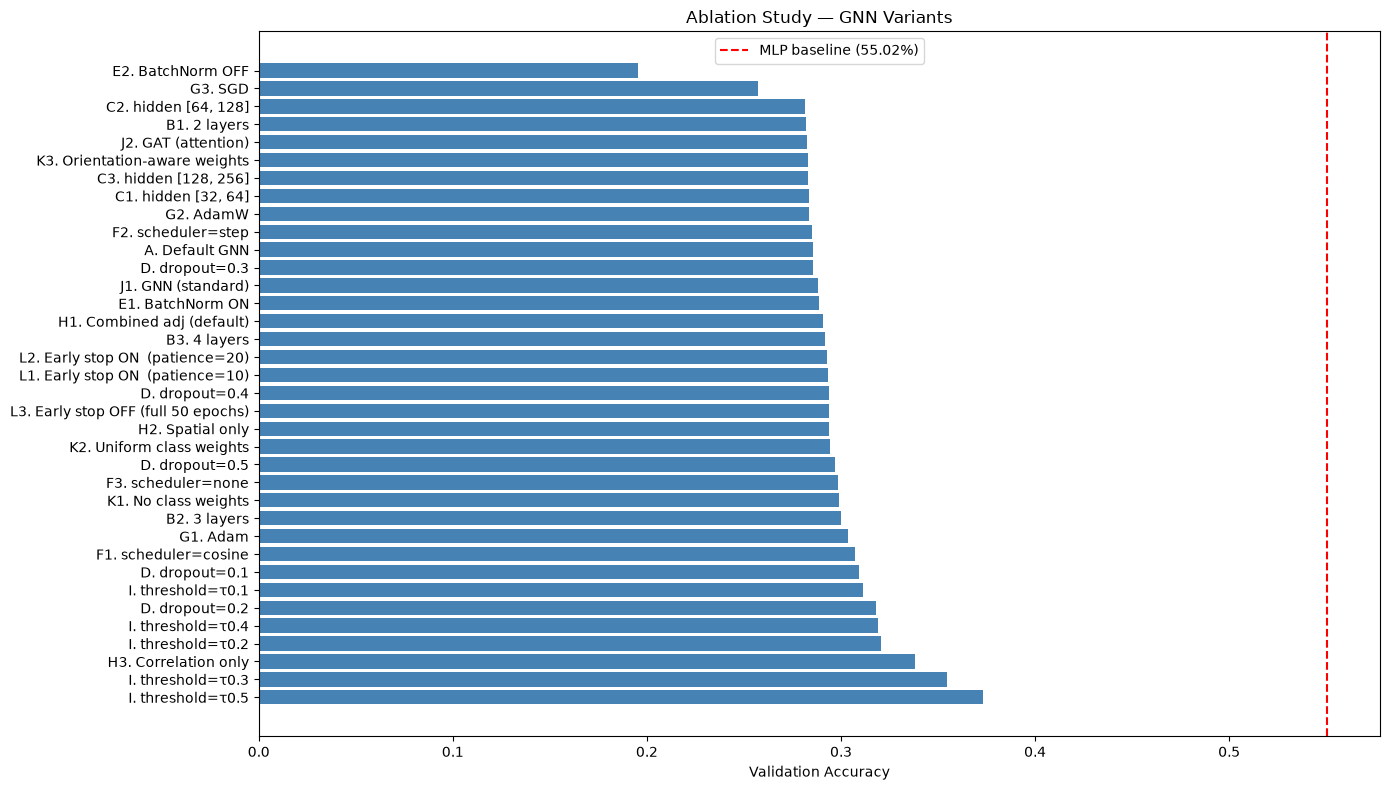

In [27]:
# ── Ablation summary table ──
abl_df = pd.DataFrame([
    {'Experiment': k, 'Val Accuracy': v['accuracy'], 'Macro F1': v['macro_f1']}
    for k, v in ablation_results.items()
]).sort_values('Val Accuracy', ascending=False)

print('=== Ablation Study Results ===')
print(abl_df.to_string(index=False))

# Plot
plt.figure(figsize=(14, 8))
bars = plt.barh(abl_df['Experiment'], abl_df['Val Accuracy'], color='steelblue')
plt.axvline(0.5502, color='red', linestyle='--', label='MLP baseline (55.02%)')
plt.xlabel('Validation Accuracy')
plt.title('Ablation Study — GNN Variants')
plt.legend()
plt.tight_layout()
plt.savefig('ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Best Configuration — Final GNN

In [28]:
# ── Train final model with best config found from ablation ──
# [UPDATE these based on your ablation results above]
BEST_CONFIG = dict(
    hidden         = [64, 128],    # UPDATE from ablation B
    out_dim        = 64,           # UPDATE from ablation C
    dropout        = 0.3,          # UPDATE from ablation D
    use_bn         = True,         # UPDATE from ablation E
    variant        = 'gnn',        # UPDATE from ablation J (try 'gat')
    optimizer      = 'adam',       # UPDATE from ablation G
    lr             = 1e-3,
    epochs         = 80,           # more epochs for final model
    batch_size     = 256,
    use_scheduler  = 'cosine',     # UPDATE from ablation F
    use_early_stop = True,
    patience       = 15,
    class_weights  = None,         # UPDATE from ablation K
)

print('Training final GNN with best configuration...')
final_model, final_best_acc, final_history = train_gnn(
    BEST_CONFIG, X_tr, A_tr, y_tr, X_v, A_v, y_v, verbose=True
)

# Evaluate on val and test
val_metrics  = eval_model(final_model, X_v,  A_v,  y_v)
test_metrics = eval_model(final_model, X_te, A_te, y_te)

print(f'\nFinal GNN — Val  Accuracy: {val_metrics["accuracy"]:.4f}  Macro F1: {val_metrics["macro_f1"]:.4f}')
print(f'Final GNN — Test Accuracy: {test_metrics["accuracy"]:.4f}  Macro F1: {test_metrics["macro_f1"]:.4f}')

Training final GNN with best configuration...
  Epoch 10/80  train_acc=0.4373  val_acc=0.2708
  Epoch 20/80  train_acc=0.4784  val_acc=0.2918
  Epoch 30/80  train_acc=0.5040  val_acc=0.2869
  Epoch 40/80  train_acc=0.5231  val_acc=0.2658
  Early stop at epoch 44

Final GNN — Val  Accuracy: 0.3055  Macro F1: 0.2792
Final GNN — Test Accuracy: 0.4076  Macro F1: 0.4039


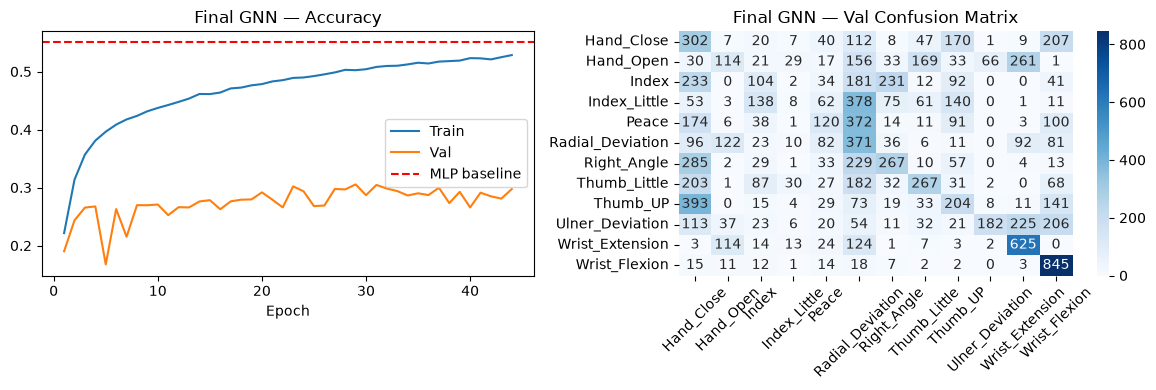

In [29]:
%matplotlib inline
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
e = range(1, len(final_history['train_acc'])+1)
axes[0].plot(e, final_history['train_acc'], label='Train')
axes[0].plot(e, final_history['val_acc'],   label='Val')
axes[0].axhline(0.5502, color='red', linestyle='--', label='MLP baseline')
axes[0].set_title('Final GNN — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(val_metrics['trues'], val_metrics['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Final GNN — Val Confusion Matrix')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('final_gnn_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5-Fold Subject Cross-Validation + Significance Test

In [30]:
# ── 5-fold subject cross-validation ──
# Split 19 subjects into 5 folds
from sklearn.model_selection import KFold

subjects = sorted(metadata.Subject.unique(),
                  key=lambda s: int(re.search(r'\d+', s).group()))
kf = KFold(n_splits=5, shuffle=False)

cv_gnn_accs = []
cv_mlp_accs = []   # MLP baseline re-run for significance test

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler as SS

def tsd_features_flat(window):
    """104-feature flat vector (baseline features) from a window."""
    feats = []
    for ch in range(N_CH):
        x = window[ch]
        feats += [np.mean(x), np.median(x), np.std(x), np.min(x), np.max(x),
                  np.sqrt(np.mean(x**2)), np.ptp(x),
                  np.percentile(x,25), np.percentile(x,75),
                  float(pd.Series(x).skew()), float(pd.Series(x).kurtosis()),
                  np.mean(np.abs(np.diff(x))), np.sum(np.abs(np.diff(x)))]
    return np.array(feats, dtype=np.float32)

print(f'Running 5-fold subject CV over {len(subjects)} subjects...')

for fold, (tr_idx, te_idx) in enumerate(kf.split(subjects), 1):
    tr_subs = [subjects[i] for i in tr_idx]
    te_subs = [subjects[i] for i in te_idx]
    print(f'\nFold {fold} — test subjects: {te_subs}')

    fold_tr = metadata[metadata.Subject.isin(tr_subs)].reset_index(drop=True)
    fold_te = metadata[metadata.Subject.isin(te_subs)].reset_index(drop=True)

    # ── GNN ──
    Xf_tr, Af_tr, yf_tr = process_split_gnn(fold_tr, make_combined_adj, f'F{fold} GNN train')
    Xf_te, Af_te, yf_te = process_split_gnn(fold_te, make_combined_adj, f'F{fold} GNN test')

    fm = Xf_tr.mean(axis=(0,2), keepdims=True)
    fs = Xf_tr.std(axis=(0,2),  keepdims=True); fs[fs==0] = 1.0
    Xf_tr = np.clip(np.nan_to_num((Xf_tr-fm)/fs), -1e6, 1e6)
    Xf_te = np.clip(np.nan_to_num((Xf_te-fm)/fs), -1e6, 1e6)

    m_fold, _, _ = train_gnn(
        BEST_CONFIG, Xf_tr, Af_tr, yf_tr,
        Xf_te, Af_te, yf_te, verbose=False
    )
    gnn_res = eval_model(m_fold, Xf_te, Af_te, yf_te)
    cv_gnn_accs.append(gnn_res['accuracy'])

    # ── MLP baseline ──
    def flat_split(df, desc):
        Xf, yf = [], []
        for _, row in tqdm(df.iterrows(), total=len(df), desc=desc, leave=False):
            raw  = sio.loadmat(row['File'])['value']
            proc = preprocess(raw)
            wins = make_windows(proc)
            for w in wins:
                Xf.append(tsd_features_flat(w))
                yf.append(le.transform([row['Gesture']])[0])
        return np.array(Xf), np.array(yf)

    Xm_tr, ym_tr = flat_split(fold_tr, f'F{fold} MLP train')
    Xm_te, ym_te = flat_split(fold_te, f'F{fold} MLP test')
    sc = SS().fit(Xm_tr)
    mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=30, random_state=42)
    mlp.fit(sc.transform(Xm_tr), ym_tr)
    mlp_acc = accuracy_score(ym_te, mlp.predict(sc.transform(Xm_te)))
    cv_mlp_accs.append(mlp_acc)

    print(f'  GNN acc: {gnn_res["accuracy"]:.4f}  |  MLP acc: {mlp_acc:.4f}')

cv_gnn_accs = np.array(cv_gnn_accs)
cv_mlp_accs = np.array(cv_mlp_accs)
print(f'\n5-Fold CV  GNN : {cv_gnn_accs.mean():.4f} ± {cv_gnn_accs.std():.4f}')
print(f'5-Fold CV  MLP : {cv_mlp_accs.mean():.4f} ± {cv_mlp_accs.std():.4f}')

Running 5-fold subject CV over 19 subjects...

Fold 1 — test subjects: ['Subject1', 'Subject2', 'Subject3', 'Subject4']


F1 GNN train:   0%|          | 0/2700 [00:00<?, ?it/s]

F1 GNN test:   0%|          | 0/720 [00:00<?, ?it/s]

F1 MLP train:   0%|          | 0/2700 [00:00<?, ?it/s]

F1 MLP test:   0%|          | 0/720 [00:00<?, ?it/s]

...

F5 GNN train:   0%|          | 0/2880 [00:00<?, ?it/s]

F5 GNN test:   0%|          | 0/540 [00:00<?, ?it/s]

F5 MLP train:   0%|          | 0/2880 [00:00<?, ?it/s]

F5 MLP test:   0%|          | 0/540 [00:00<?, ?it/s]

  GNN acc: 0.4296  |  MLP acc: 0.6135

5-Fold CV  GNN : 0.3656 ± 0.0530
5-Fold CV  MLP : 0.5136 ± 0.0733


=== Significance Test: GNN vs MLP Baseline ===
Wilcoxon statistic : 0.0000
p-value            : 0.0625
Significant (α=0.05): NO



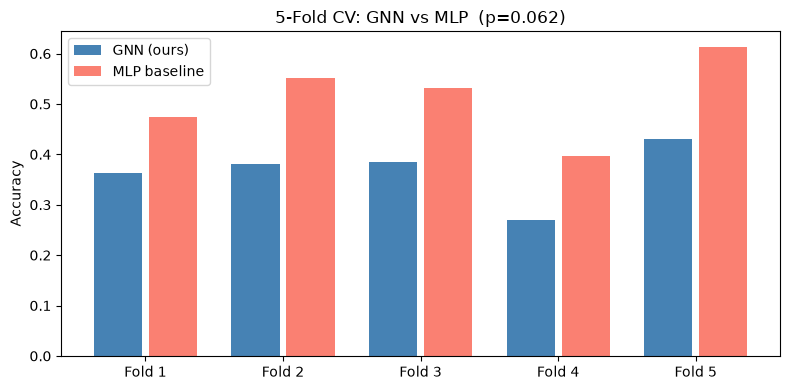

In [31]:
# ── Wilcoxon signed-rank significance test ──
stat, p_value = wilcoxon(cv_gnn_accs, cv_mlp_accs)
alpha = 0.05

print('=== Significance Test: GNN vs MLP Baseline ===')
print(f'Wilcoxon statistic : {stat:.4f}')
print(f'p-value            : {p_value:.4f}')
print(f'Significant (α={alpha}): {"YES" if p_value < alpha else "NO"}')
print()

# 5-fold CV comparison bar chart
x = np.arange(5)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, cv_gnn_accs, 0.35, label='GNN (ours)', color='steelblue')
ax.bar(x + 0.2, cv_mlp_accs, 0.35, label='MLP baseline', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Accuracy')
ax.set_title(f'5-Fold CV: GNN vs MLP  (p={p_value:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Comparison Table

In [32]:
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression',        'Val Acc': 0.5006, 'Macro F1': 0.5097, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'k-NN',                       'Val Acc': 0.4254, 'Macro F1': 0.4080, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'Decision Tree',              'Val Acc': 0.3532, 'Macro F1': 0.3492, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'SVM (LinearSVC)',            'Val Acc': 0.4621, 'Macro F1': 0.4651, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'Gradient Boosting',          'Val Acc': 0.4903, 'Macro F1': 0.4839, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'XGBoost',                    'Val Acc': 0.5119, 'Macro F1': 0.5132, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'LightGBM',                   'Val Acc': 0.5193, 'Macro F1': 0.5207, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'Random Forest',              'Val Acc': 0.5145, 'Macro F1': 0.5011, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': '1D-CNN',                     'Val Acc': 0.5241, 'Macro F1': 0.5138, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'MLP (best baseline)',        'Val Acc': 0.5502, 'Macro F1': 0.5457, 'Protocol': 'Subject-wise', 'Source': 'Task 2 baseline'},
    {'Model': 'GNN — Task 2 first result', 'Val Acc': val_metrics['accuracy'],  'Macro F1': val_metrics['macro_f1'],  'Protocol': 'Subject-wise', 'Source': 'Task 2 GNN'},
    {'Model': 'GNN — Task 3 final',        'Val Acc': test_metrics['accuracy'], 'Macro F1': test_metrics['macro_f1'], 'Protocol': 'Subject-wise', 'Source': 'Task 3 (this notebook)'},
    {'Model': 'Çelik & Can (2026)',         'Val Acc': 0.7400, 'Macro F1': 0.7370, 'Protocol': 'Subject-wise', 'Source': 'Published benchmark'},
    {'Model': 'Aarotale 2024 (RF+TSD)',     'Val Acc': 0.9495, 'Macro F1': 0.9495, 'Protocol': 'Random split*', 'Source': 'Published (different protocol)'},
]).sort_values('Val Acc', ascending=False)

print('=== Final Model Comparison ===')
print(comparison.to_string(index=False))
print('\n* Random split not directly comparable to subject-wise results.')

=== Final Model Comparison ===
                    Model  Val Acc  Macro F1      Protocol                         Source
   Aarotale 2024 (RF+TSD) 0.949500  0.949500 Random split* Published (different protocol)
       Çelik & Can (2026) 0.740000  0.737000  Subject-wise            Published benchmark
      MLP (best baseline) 0.550200  0.545700  Subject-wise                Task 2 baseline
                   1D-CNN 0.524100  0.513800  Subject-wise                Task 2 baseline
                 LightGBM 0.519300  0.520700  Subject-wise                Task 2 baseline
            Random Forest 0.514500  0.501100  Subject-wise                Task 2 baseline
                  XGBoost 0.511900  0.513200  Subject-wise                Task 2 baseline
      Logistic Regression 0.500600  0.509700  Subject-wise                Task 2 baseline
        Gradient Boosting 0.490300  0.483900  Subject-wise                Task 2 baseline
          SVM (LinearSVC) 0.462100  0.465100  Subject-wise           

## SHAP + LIME Explainability

In [33]:
import shap

# ── SHAP on flattened node features ──
# We use a wrapper that flattens (8,7) → 56-dim for SHAP compatibility
from sklearn.ensemble import RandomForestClassifier

# Build flat TSD feature set for SHAP (interpretable feature names)
TSD_NAMES = ['M0','M2','M4','Sparseness','IRF','COV','TKEO']
FEATURE_NAMES = [f'CH{ch+1}_{f}' for ch in range(8) for f in TSD_NAMES]  # 56 features

def window_to_flat_tsd(w):
    return extract_node_features(w).flatten()  # (8,7) → (56,)

# Build flat dataset (train subset for speed)
print('Building flat TSD dataset for SHAP...')
X_shap_tr = X_tr.reshape(len(X_tr), -1)  # (N, 56)
X_shap_v  = X_v.reshape(len(X_v), -1)

# Train a RF on flat features (SHAP is cleaner with tree models)
rf_shap = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_shap.fit(X_shap_tr, y_tr)
print(f'RF (for SHAP) val acc: {accuracy_score(y_v, rf_shap.predict(X_shap_v)):.4f}')

# SHAP TreeExplainer
explainer_shap = shap.TreeExplainer(rf_shap)

# Explain 200 val samples
sample_idx = np.random.choice(len(X_shap_v), 200, replace=False)
shap_values = explainer_shap.shap_values(X_shap_v[sample_idx])

print('SHAP values computed.')

Building flat TSD dataset for SHAP...
RF (for SHAP) val acc: 0.4575


KeyboardInterrupt: 

In [ ]:
%matplotlib inline
# SHAP summary plot (mean |SHAP| across all classes)
shap_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (200, 56)
feature_importance = shap_mean.mean(axis=0)                        # (56,)

fi_df = pd.DataFrame({'Feature': FEATURE_NAMES, 'Mean |SHAP|': feature_importance})
fi_df = fi_df.sort_values('Mean |SHAP|', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(fi_df['Feature'], fi_df['Mean |SHAP|'], color='steelblue')
plt.xlabel('Mean |SHAP value|')
plt.title('SHAP Feature Importance — Top 20 Node Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
print(fi_df.head(5).to_string(index=False))

In [ ]:
# SHAP per-class heatmap (which channels matter most per gesture)
# Reshape SHAP per class to (8 channels × 7 features)
gesture_names = list(le.classes_)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for cls_idx, ax in enumerate(axes.flat):
    if cls_idx >= N_CLASSES: break
    sv_cls = np.abs(shap_values[cls_idx]).mean(axis=0).reshape(8, 7)
    sns.heatmap(sv_cls, ax=ax, cmap='YlOrRd',
                xticklabels=TSD_NAMES,
                yticklabels=[f'CH{i+1}' for i in range(8)],
                cbar=False)
    ax.set_title(gesture_names[cls_idx], fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('SHAP per Gesture — Channel × Feature Importance', y=1.01)
plt.tight_layout()
plt.savefig('shap_per_gesture.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X_shap_tr,
    feature_names=FEATURE_NAMES,
    class_names=gesture_names,
    discretize_continuous=True,
    random_state=42
)

def gnn_predict_flat(X_flat):
    """LIME-compatible predict_proba wrapper for the GNN."""
    # Reshape back to (B, 8, 7)
    X_node = X_flat.reshape(-1, N_CH, 7).astype(np.float32)
    # Use fixed average adjacency for LIME (LIME perturbs features, not graph)
    A_fixed = normalize_adj(make_spatial_adj())
    A_batch  = np.tile(A_fixed, (len(X_node), 1, 1)).astype(np.float32)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_node), torch.tensor(A_batch)),
        batch_size=256, shuffle=False
    )
    final_model.eval()
    probs = []
    with torch.no_grad():
        for Xb, Ab in loader:
            out = final_model(Xb.to(device), Ab.to(device))
            probs.append(F.softmax(out, dim=-1).cpu().numpy())
    return np.concatenate(probs)

print('LIME explainer ready.')

In [ ]:
%matplotlib inline
# LIME explanation for one CORRECT prediction
preds_v = val_metrics['preds']
trues_v = val_metrics['trues']

correct_idx = np.where(preds_v == trues_v)[0]
wrong_idx   = np.where(preds_v != trues_v)[0]

for label, sample_i in [('CORRECT', correct_idx[0]), ('WRONG', wrong_idx[0])]:
    exp = lime_explainer.explain_instance(
        X_shap_v[sample_i],
        gnn_predict_flat,
        num_features=10,
        top_labels=1
    )
    true_gesture  = gesture_names[trues_v[sample_i]]
    pred_gesture  = gesture_names[preds_v[sample_i]]
    print(f'\n[{label}] True: {true_gesture}  |  Predicted: {pred_gesture}')
    fig = exp.as_pyplot_figure(label=exp.top_labels[0])
    fig.suptitle(f'LIME — {label} sample\nTrue: {true_gesture}  Predicted: {pred_gesture}')
    plt.tight_layout()
    plt.savefig(f'lime_{label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Save Final Model

In [ ]:
import os
os.makedirs('models', exist_ok=True)
torch.save({
    'model_state_dict': final_model.state_dict(),
    'config'          : BEST_CONFIG,
    'label_encoder'   : le.classes_.tolist(),
    'feat_mean'       : feat_mean,
    'feat_std'        : feat_std,
    'val_accuracy'    : val_metrics['accuracy'],
    'test_accuracy'   : test_metrics['accuracy'],
    'cv_gnn_mean'     : float(cv_gnn_accs.mean()),
    'cv_gnn_std'      : float(cv_gnn_accs.std()),
    'wilcoxon_p'      : float(p_value),
}, 'models/gnn_final.pt')

print('Model saved to models/gnn_final.pt')
print()
print('=== Final Summary ===')
print(f'Val  Accuracy : {val_metrics["accuracy"]:.4f}')
print(f'Test Accuracy : {test_metrics["accuracy"]:.4f}')
print(f'5-Fold CV     : {cv_gnn_accs.mean():.4f} ± {cv_gnn_accs.std():.4f}')
print(f'Wilcoxon p    : {p_value:.4f} ({"significant" if p_value < 0.05 else "not significant"})')
print(f'MLP baseline  : 0.5502')
print(f'Improvement   : {val_metrics["accuracy"] - 0.5502:+.4f}')